In [24]:
# EC1: Thakurgaon Location Context Map (3-panel)
# Cell 1 — Imports, paths, and data loading
# ============================================================

import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as ticker
from matplotlib.patches import Rectangle, ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- Paths (relative — works after cloning the repo, no drive letter needed) ---
bangladesh_path   = "data/boundaries/Bangladesh_Country_Boundary.gpkg"
thakurgaon_path   = "data/boundaries/thakurgaon_district.gpkg"
sadar_path        = "data/boundaries/thakurgaon_sadar.gpkg"
output_path       = "outputs/EC1_Thakurgaon_Location_Context.png"
NORTH_ARROW_FILE  = "assets/north_arrow.png"

# --- Load data ---
bangladesh = gpd.read_file(bangladesh_path).to_crs(epsg=4326)

thakurgaon_district = gpd.read_file(thakurgaon_path, layer="thakurgaon_district").to_crs(epsg=4326)
thakurgaon_upazilas = gpd.read_file(thakurgaon_path, layer="thakurgaon_upazilas").to_crs(epsg=4326)

thakurgaon_sadar = gpd.read_file(sadar_path, layer="thakurgaon_district__thakurgaon_sadar").to_crs(epsg=4326)

upazilas_other = thakurgaon_upazilas[thakurgaon_upazilas['NAME_3'] != 'Thakurgaon Sadar']
upazila_sadar  = thakurgaon_upazilas[thakurgaon_upazilas['NAME_3'] == 'Thakurgaon Sadar']

print("Data loaded successfully.")

Data loaded successfully.


In [25]:
# Cell 2 — Style setup and helper functions
# ============================================================

FONT = 'Georgia'
BASEMAP_ALPHA = 0.45

plt.rcParams.update({
    'font.family': FONT,
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6
})

deg_lon = ticker.FuncFormatter(lambda x, pos: f"{x:.2f}°E")
deg_lat = ticker.FuncFormatter(lambda y, pos: f"{y:.2f}°N")

LEGEND_KW = dict(fontsize=8.4, prop={'family': FONT, 'size': 8.4},
                  frameon=True, framealpha=0.9, edgecolor='black',
                  borderpad=1.2, labelspacing=1.2, handlelength=2.4,
                  handletextpad=1.2, borderaxespad=1.2)

LEGEND_KW_BC = {**LEGEND_KW, 'framealpha': 0.65}


def add_osm_basemap(ax):
    ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldStreetMap,
                     alpha=BASEMAP_ALPHA, attribution=False, zorder=0)


def style_map_axis(ax, panel_label=None):
    ax.grid(True, linestyle=':', alpha=0.6, color='black', linewidth=0.5, zorder=1)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(deg_lon)
    ax.yaxis.set_major_formatter(deg_lat)
    ax.tick_params(axis='x', labelsize=9, bottom=True, top=True,
                    labelbottom=True, labeltop=True)
    ax.tick_params(axis='y', labelsize=9, left=True, right=True,
                    labelleft=True, labelright=True, labelrotation=90)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_verticalalignment('center')
        tick.label2.set_verticalalignment('center')
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily(FONT)
    if panel_label:
        ax.text(0.5, 0.97, panel_label, transform=ax.transAxes,
                fontsize=28, fontweight='bold', fontfamily=FONT,
                va='top', ha='center', zorder=10,
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    ax.set_aspect('equal')


def add_compass(ax):
    axins = inset_axes(ax, width='16%', height='16%', loc='upper right', borderpad=0.6)
    axins.axis('off')
    try:
        img = plt.imread(NORTH_ARROW_FILE)
        axins.imshow(img, interpolation='hanning')
    except Exception as e:
        print(f"North arrow not loaded: {e}")


def add_scale_bar(ax, bar_km_labels=(0, 1, 2)):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    full_len = (x1 - x0) * 0.18
    bar_x, bar_y = x0 + (x1 - x0) * 0.03, y0 + (y1 - y0) * 0.03
    bar_height = (y1 - y0) * 0.008
    lp = {'ha': 'center', 'va': 'bottom', 'fontsize': 9, 'fontweight': 'bold', 'zorder': 10}

    if len(bar_km_labels) == 2:
        ax.add_patch(Rectangle((bar_x, bar_y), full_len, bar_height,
                                facecolor='black', edgecolor='black', zorder=10))
        ax.text(bar_x, bar_y + (y1 - y0) * 0.02, str(bar_km_labels[0]), **lp)
        ax.text(bar_x + full_len, bar_y + (y1 - y0) * 0.02, str(bar_km_labels[1]), **lp)
    else:
        half_len = full_len / 2
        for r in [Rectangle((bar_x, bar_y), half_len, bar_height,
                             facecolor='black', edgecolor='black', zorder=10),
                  Rectangle((bar_x + half_len, bar_y), half_len, bar_height,
                             facecolor='white', edgecolor='black', zorder=10)]:
            ax.add_patch(r)
        ax.text(bar_x, bar_y + (y1 - y0) * 0.02, str(bar_km_labels[0]), **lp)
        ax.text(bar_x + half_len, bar_y + (y1 - y0) * 0.02, str(bar_km_labels[1]), **lp)
        ax.text(bar_x + full_len, bar_y + (y1 - y0) * 0.02, str(bar_km_labels[2]), **lp)

    ax.text(bar_x + full_len + (x1 - x0) * 0.018, bar_y + (y1 - y0) * 0.005, 'km',
            ha='left', va='center', fontsize=9, fontweight='bold', zorder=10)


def add_zoom_connector(fig, ax_from, ax_to, bbox, side='right', color='#1f78b4', lw=1.4):
    minx, miny, maxx, maxy = bbox
    rect = Rectangle((minx, miny), maxx - minx, maxy - miny,
                      fill=False, edgecolor=color, linewidth=lw, zorder=25)
    ax_from.add_patch(rect)

    if side == 'right':
        cornerA_top = (maxx, maxy)
        cornerA_bot = (maxx, miny)
        cornerB_top = (0, 1)
        cornerB_bot = (0, 0)
    else:
        cornerA_top = (minx, maxy)
        cornerA_bot = (minx, miny)
        cornerB_top = (1, 1)
        cornerB_bot = (1, 0)

    for xyA, xyB in [(cornerA_top, cornerB_top), (cornerA_bot, cornerB_bot)]:
        con = ConnectionPatch(xyA=xyA, coordsA=ax_from.transData,
                               xyB=xyB, coordsB=ax_to.transAxes,
                               color=color, linewidth=lw, zorder=25)
        fig.add_artist(con)

print("Style setup and helper functions loaded.")

Style setup and helper functions loaded.


C:\Users\user\AppData\Local\Temp\ipykernel_21980\2658306660.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


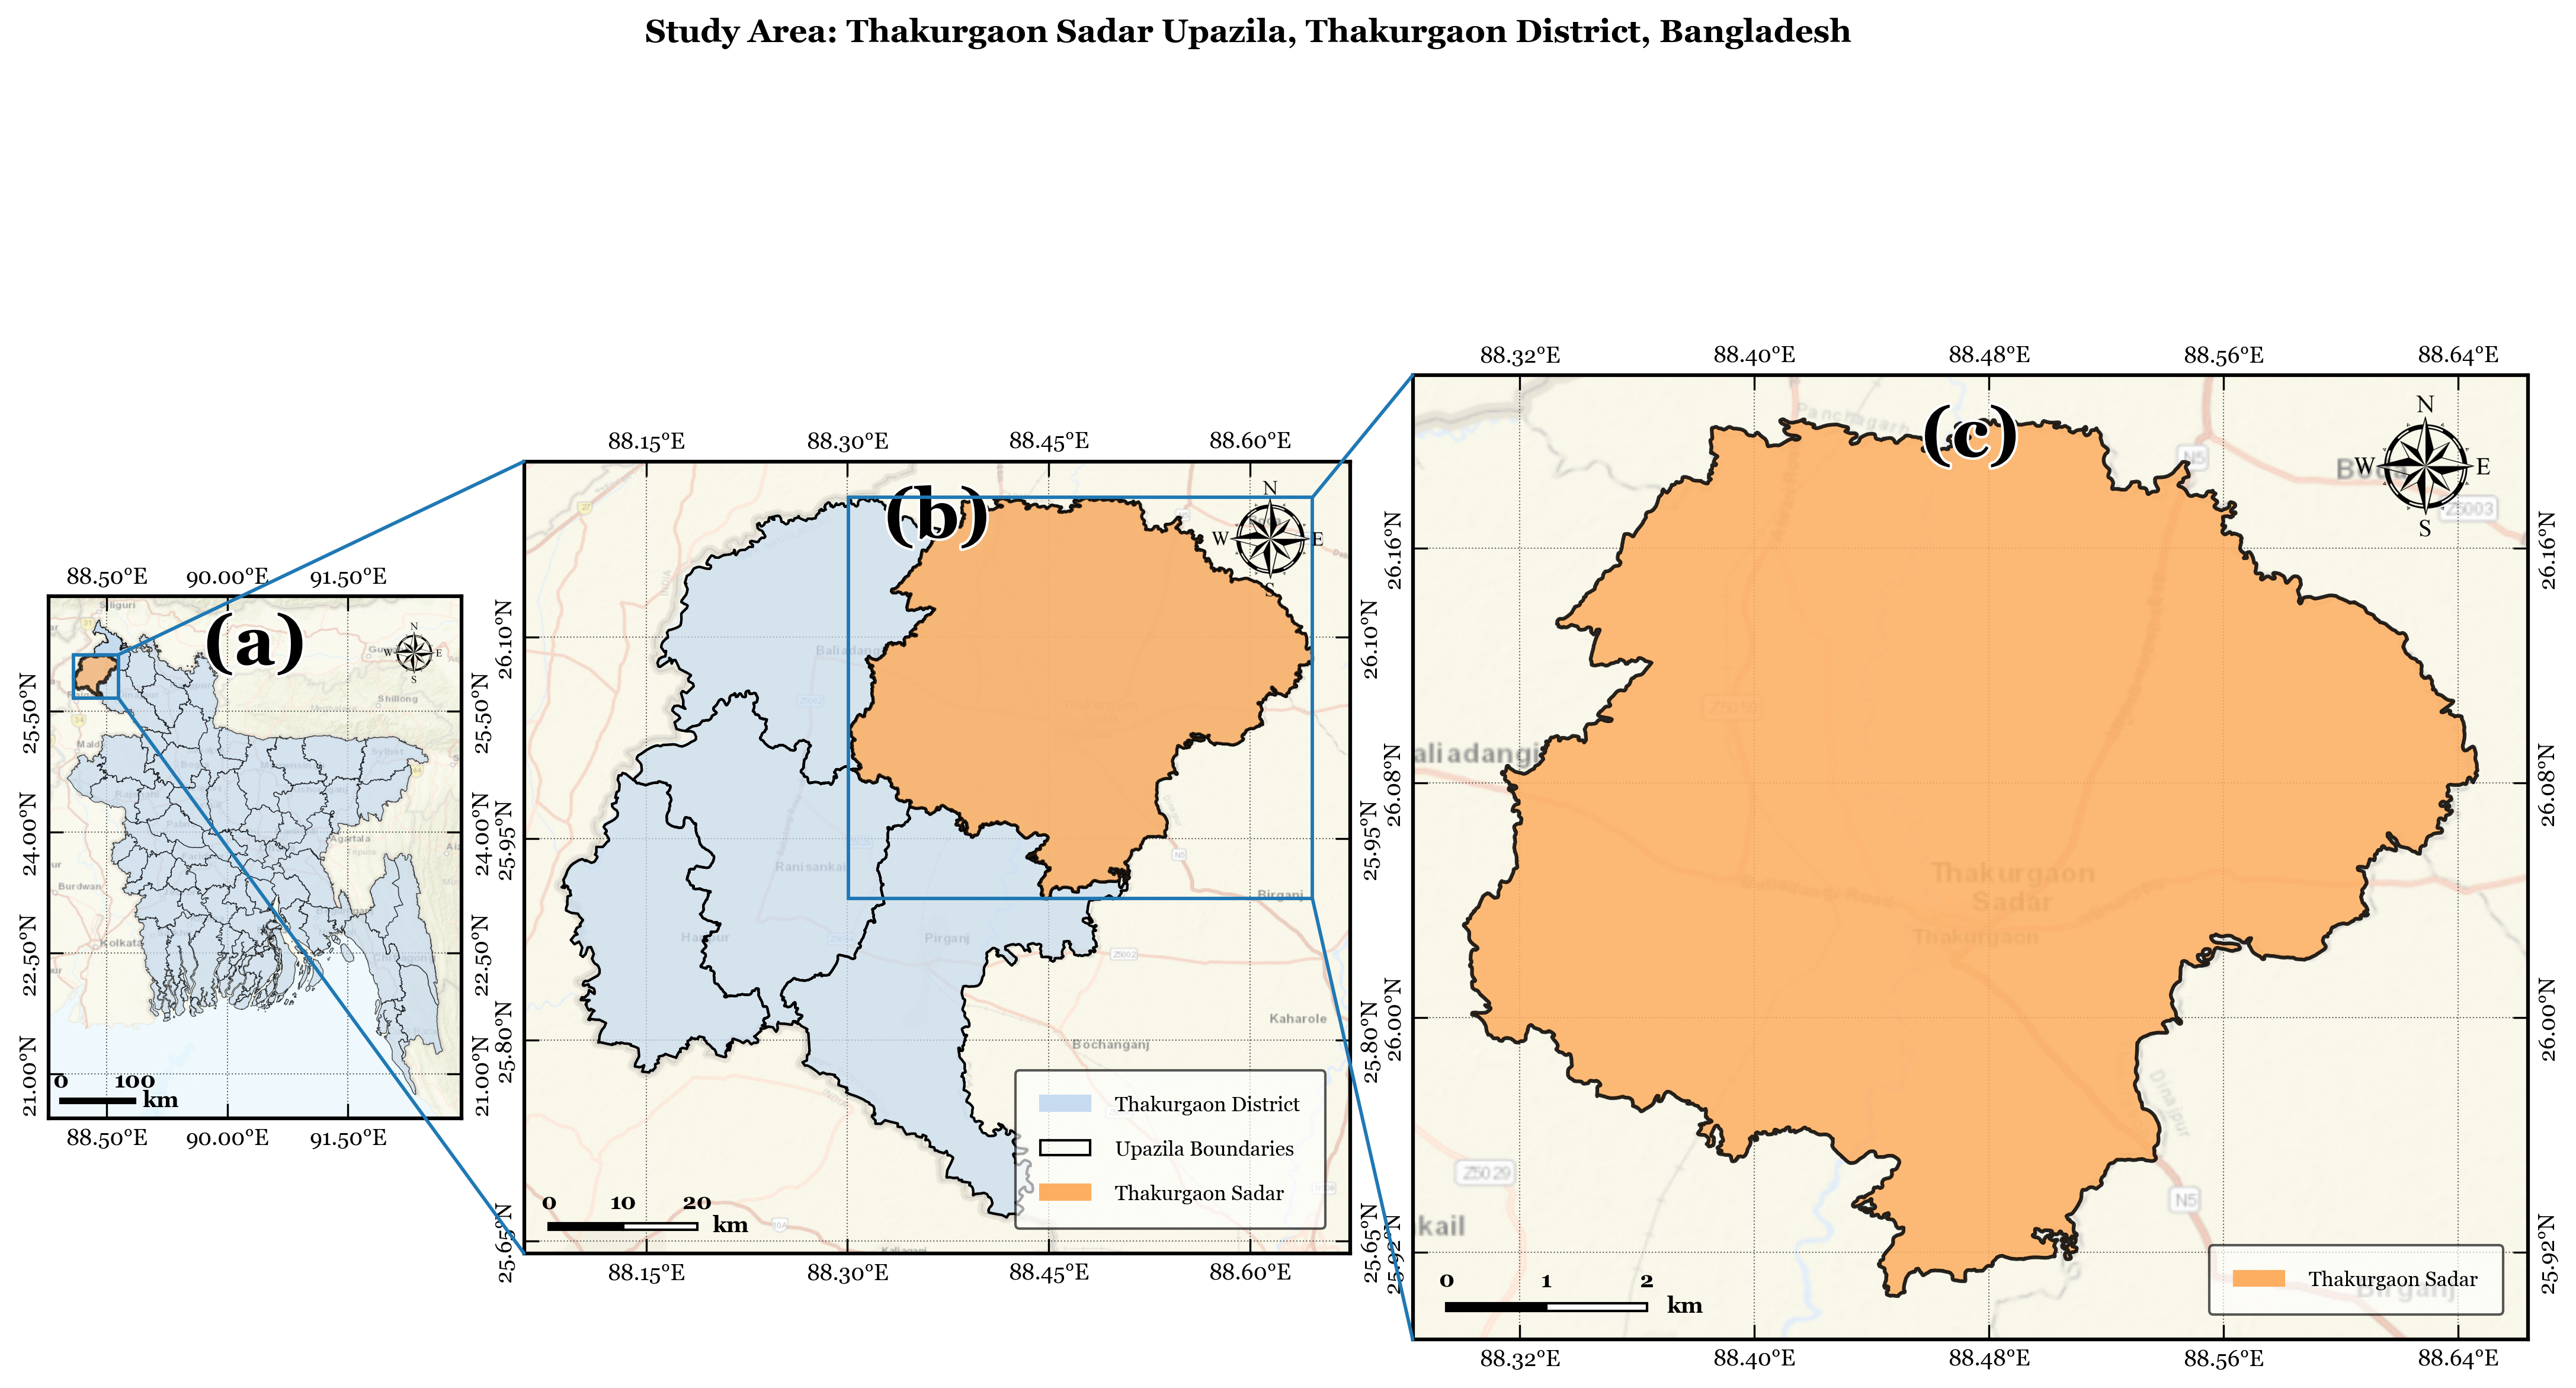

Saved: outputs/EC1_Thakurgaon_Location_Context.png


In [26]:
# Cell 3 — Build the 3-panel figure and save
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 9), dpi=300,
                          gridspec_kw={'width_ratios': [0.5, 1.0, 1.35], 'wspace': 0.08})
fig.patch.set_facecolor('white')

# ── Panel A ───────────────────────────────────────────────────────────────
ax1 = axes[0]
bangladesh.plot(ax=ax1, color='#c6dbef', edgecolor='black', linewidth=0.3,
                 alpha=0.7, zorder=2)
thakurgaon_district.plot(ax=ax1, color='#fdae61', edgecolor='black', linewidth=1.3,
                          alpha=0.7, zorder=3)
add_osm_basemap(ax1)
style_map_axis(ax1, '(a)')
add_compass(ax1)
add_scale_bar(ax1, bar_km_labels=(0, 100))

# ── Panel B ───────────────────────────────────────────────────────────────
ax2 = axes[1]
thakurgaon_district.plot(ax=ax2, color='#c6dbef', edgecolor='black', linewidth=0.8,
                          alpha=0.7, zorder=2)
upazilas_other.plot(ax=ax2, color='none', edgecolor='black', linewidth=1.0, zorder=3)
upazila_sadar.plot(ax=ax2, color='#fdae61', edgecolor='black', linewidth=1.3,
                    alpha=0.85, zorder=4)
add_osm_basemap(ax2)
style_map_axis(ax2, '(b)')
add_compass(ax2)
add_scale_bar(ax2, bar_km_labels=(0, 10, 20))

p3 = mpatches.Patch(color='#c6dbef', label='Thakurgaon District')
p4 = mpatches.Patch(facecolor='none', edgecolor='black', label='Upazila Boundaries')
p5 = mpatches.Patch(color='#fdae61', label='Thakurgaon Sadar')
ax2.legend(handles=[p3, p4, p5], loc='lower right', **LEGEND_KW_BC)
ax2.set_anchor('E')

# ── Panel C ───────────────────────────────────────────────────────────────
ax3 = axes[2]
thakurgaon_sadar.plot(ax=ax3, color='#fdae61', edgecolor='black', linewidth=1.5,
                       alpha=0.85, zorder=3)
add_osm_basemap(ax3)
style_map_axis(ax3, '(c)')
add_compass(ax3)
add_scale_bar(ax3, bar_km_labels=(0, 1, 2))

p6 = mpatches.Patch(color='#fdae61', label='Thakurgaon Sadar')
ax3.legend(handles=[p6], loc='lower right', **LEGEND_KW_BC)
ax3.set_anchor('W')

fig.suptitle('Study Area: Thakurgaon Sadar Upazila, Thakurgaon District, Bangladesh',
             fontsize=13, fontfamily=FONT, fontweight='bold', y=1.02)

plt.tight_layout()

bounds_thakurgaon = thakurgaon_district.total_bounds
bounds_sadar_in_b = upazila_sadar.total_bounds

add_zoom_connector(fig, ax1, ax2, bounds_thakurgaon, side='right')
add_zoom_connector(fig, ax2, ax3, bounds_sadar_in_b, side='right')

plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {output_path}")